In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam
from keras.optimizers import Adam

In [3]:
# Load grayscale dataset (32x32x1)
df = pd.read_csv("GestureDataset_32x32x1.csv", header=None)

# Split labels and features
Y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values.astype('float32') / 255.0

# Encode class labels
encoder = LabelEncoder()
Y = encoder.fit_transform(Y)

# Split into training and testing sets
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Reshape to (samples, 32, 32, 1)
Xtrain = Xtrain.reshape((Xtrain.shape[0], 32, 32, 1))
Xtest = Xtest.reshape((Xtest.shape[0], 32, 32, 1))

# One-hot encode labels
num_classes = len(np.unique(Y))
Ytrain = to_categorical(Ytrain, num_classes)
Ytest = to_categorical(Ytest, num_classes)

In [4]:
# Build LeNet model
model = Sequential()
model.add(Conv2D(6, (5,5), activation='tanh', input_shape=(32,32,1), padding='same'))
model.add(AveragePooling2D(pool_size=(2,2)))
model.add(Conv2D(16, (5,5), activation='tanh'))
model.add(AveragePooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

# Compile
optimizer = Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

c:\Python\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Train
history = model.fit(Xtrain, Ytrain, validation_data=(Xtest, Ytest), epochs=20, batch_size=64, verbose=1)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.3150 - loss: 1.0996 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.3288 - loss: 1.1001 - val_accuracy: 0.3333 - val_loss: 1.0997
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3350 - loss: 1.0990 - val_accuracy: 0.3333 - val_loss: 1.1033
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3083 - loss: 1.1027 - val_accuracy: 0.3333 - val_loss: 1.0993
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3204 - loss: 1.1000 - val_accuracy: 0.3333 - val_loss: 1.0990
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3392 - loss: 1.0998 - val_accuracy: 0.3333 - val_loss: 1.0989
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3438 - loss: 1.0992 - val_accuracy: 0.3333 - val_loss: 1.0994
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3208 - loss: 1.1000 - val_accuracy: 0.3333 - v

Training Accuracy = 0.3266666531562805
Testing Accuracy = 0.3333333432674408


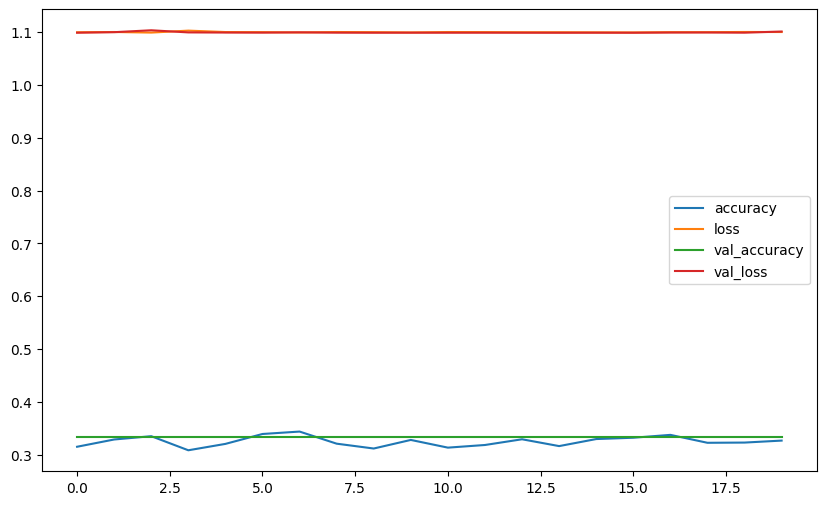

In [6]:
# Results
print("Training Accuracy =", history.history['accuracy'][-1])
print("Testing Accuracy =", history.history['val_accuracy'][-1])

# Plot training vs testing
pd.DataFrame(history.history).plot(figsize=(10,6))
plt.show()